# Unit Root Testing

In [36]:
%load_ext pretty_jupyter

The pretty_jupyter extension is already loaded. To reload it, use:
  %reload_ext pretty_jupyter


## Introduction
In time-series modeling, accurately understanding the properties of the series used is crucial. It is well established that standard statistical inference in regression models relies on the time series being stationary. Non-stationary series can lead to unreliable and misleading statistical inferences, making it essential to verify the stationarity of the data.

In this walkthrough, we will demonstrate how to utilize the Augmented Dickey-Fuller (ADF) test to establish whether a time series, or a differenced version of it, is stationary. This step is critical in preparing time series data for effective analysis and modeling. We'll also explore methods for transforming non-stationary data into stationary data, thus ensuring the robustness of our statistical conclusions.

By focusing on these techniques, you will gain the ability to accurately assess and prepare your time series data for any subsequent analyses or modeling tasks.

## Data and Library Setup
In order to work on this problem lets ensure all necessary Python packages are installed and imported:

In [56]:
!pip install lets-plot

In [59]:
import pandas as pd                            # for data manipulation
import numpy as np                             # for data manipulation
import requests                                # for handling HTTP requests to download data or interact with APIs.
from lets_plot import *                        # Import all components from lets_plot for data visualization
LetsPlot.setup_html()                          # Setup lets_plot to display plots directly in the HTML output of a notebook
from statsmodels.tsa.stattools import adfuller # used for statistical tests like the Augmented Dickey-Fuller (ADF) test.
import matplotlib.pyplot as plt                # included as a fallback for plotting not covered by lets_plot.

> The `import requests` statement in Python is used to include the requests library in your script. The requests library is one of the most popular and user-friendly HTTP libraries available in Python. It simplifies sending HTTP requests to web servers, which is crucial for web scraping, downloading data from the internet, interacting with APIs (Application Programming Interfaces), and handling network communication tasks.

The data we shall use come from the FRED-MD database. This is a prepared database of macro variables for the U.S. (see McCracken and Ng, 2016). If you wish to learn more about this very useful dataset refer to this [walkthrough](https://datasquad.github.io/ECLR/Ex/FRED_MD.html) which discusses the finer detail of this dataset.

In [70]:
# URL of the current dataset
url = "https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv"

Let's say you want to ensure the dataset URL is accessible before attempting to load it. In this case, you can use the `check_url` function. This function checks the availability of the URL and helps prevent errors that could occur from trying to access or download data from an unresponsive or incorrect URL.

In [72]:
# Function to check if the URL is accessible
def check_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()  # Will raise an HTTPError if the HTTP request returned an unsuccessful status code
        return True
    except requests.exceptions.HTTPError as err:
        print(f"HTTP error occurred: {err}")  # Not an HTTP 200 OK
    except Exception as err:
        print(f"An error occurred: {err}")
    return False

In [76]:
# If URL is accessible, load the data
if check_url(url):
    # Load the data with 'date' column as a datetime index
    data = pd.read_csv(url, parse_dates=['sasdate'], index_col='sasdate')
    print("Data loaded successfully with datetime index.")

Data loaded successfully with datetime index.


C:\Users\Admin\AppData\Local\Temp\ipykernel_10872\1689366415.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(url, parse_dates=['sasdate'], index_col='sasdate')


However, when you run the above line of code you get a "warning message"! The warning you're seeing when loading the dataset is related to how pandas is parsing the `sasdate` column as dates. Pandas is **unsure of the date format** and is defaulting to using `dateutil` to parse each date individually, which can be less efficient and might lead to inconsistent results if the date formats vary within the column!

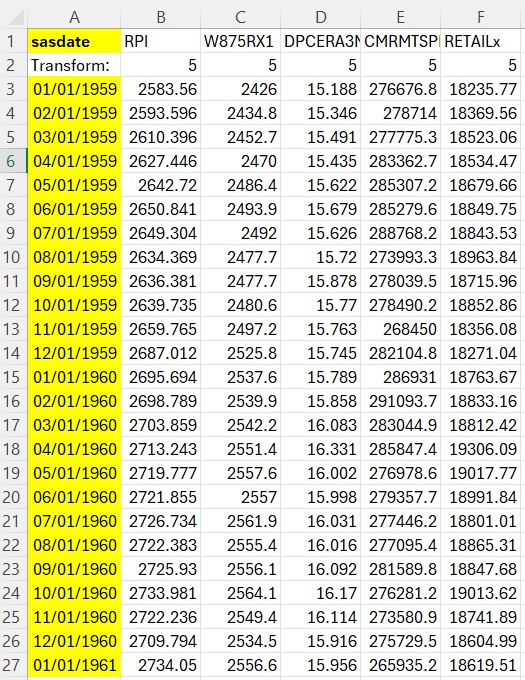

To **resolve this issue** and **avoid the warning**, you can specify the **exact format of the dates** in the `sasdate` column if you know it, or use a more **robust method** to ensure that dates are parsed correctly. Here's how you can adjust your code:

[//]: # (-.- .tabset)

##### Option 1: Specify the Date Format
If you know the format of the dates in the `sasdate` column, you can specify it directly using the `format` parameter. Common date formats include:

- `%Y-%m-%d` for 'Year-Month-Day'
- `%m/%d/%Y` for 'Month/Day/Year'
For example, if your dates are in the format 'Year-Month-Day' (e.g., '2024-10-31'), modify the read_csv function like this:

In [ ]:
data = pd.read_csv(url, parse_dates=['sasdate'], date_parser=lambda x: pd.to_datetime(x, format='%Y-%m-%d'), index_col='sasdate')

##### Option 2: Robust Date Parsing
If the date format might vary or if you're unsure about the format, you can use pandas’ `to_datetime` function without specifying a format, which attempts to infer the format of each date string. It's more flexible but can be slower:

In [ ]:
data = pd.read_csv(url, index_col='sasdate')
data.index = pd.to_datetime(data.index, errors='coerce')  # Coerce errors will turn problematic data into NaT (Not a Time)

This method tries to convert the index to datetime while handling any errors by converting problematic data into `NaT` (not a time), thus ensuring that all index values are treated as datetime objects where possible.

##### Updated Code Example
Here's how your entire block might look with one of these improvements:

In [ ]:
import pandas as pd
import requests

def check_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return True
    except requests.exceptions.RequestException as e:
        print(f"Error: {e}")
        return False

url = "https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv"
if check_url(url):
    # Load the data with a specified date format or robust parsing
    data = pd.read_csv(url, index_col='sasdate')
    data.index = pd.to_datetime(data.index, errors='coerce')  # Parsing dates robustly
    print("Data loaded successfully with datetime index.")
    print(data.head())
else:
    print("Failed to retrieve data.")


Choose the option that best suits your data's format and needs. This adjustment should help you handle the date parsing more effectively and eliminate the warning.

[//]: # (-.- .unlisted .unnumbered)

## Setting Up Time-Series Data in Python

The dataset we are working with includes 126 macroeconomic variables and a `date` variable where the dates are stored. For time-series analysis techniques such as the Augmented Dickey-Fuller (ADF) test, Python must recognize the data structure as time-series. Initially, the data frame loaded from a CSV file treats all columns as generic types; the `sasdate` column holds date information but is not automatically recognized as a time-series index, and other series are just seen as numerical data.

To effectively conduct time-series analysis in Python, we need to format the data appropriately:

- **Setting the Time Index:** The first step is to set the date column as the datetime index of the data frame. This allows Python to understand that the data are indeed time series, facilitating easier slicing and manipulation based on time intervals.
- **Using pandas for Time-Series:** While **R** might use the `zoo` package for managing time-series data, **Python** leverages the `pandas` library. Pandas provides robust tools for handling time-series data, such as resampling, time shifts, and window functions, which are essential for any form of time-series manipulation.

In [107]:
import pandas as pd

# Load the dataset
url = "https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv"
# Adjust the date format to 'Month/Day/Year'
data = pd.read_csv(url, parse_dates=['sasdate'], date_parser=lambda x: pd.to_datetime(x, format='%m/%d/%Y'), index_col='sasdate')

# Display the first two rows of the dataset
print("First two rows of the dataset:")
print(data.head(2))


C:\Users\Admin\AppData\Local\Temp\ipykernel_10872\3796095509.py:6: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  data = pd.read_csv(url, parse_dates=['sasdate'], date_parser=lambda x: pd.to_datetime(x, format='%m/%d/%Y'), index_col='sasdate')


ValueError: time data "Transform:" doesn't match format "%m/%d/%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Why do you get this **Warning Message**? 

It seems like the dataset may contain *unexpected values* or *metadata* rows that are interfering with the date parsing process. The error message indicates that a value "Transform:" was encountered, which clearly isn't a date and hence doesn't match the specified date format. This might be from a header, footer, or comment row within the CSV file. 

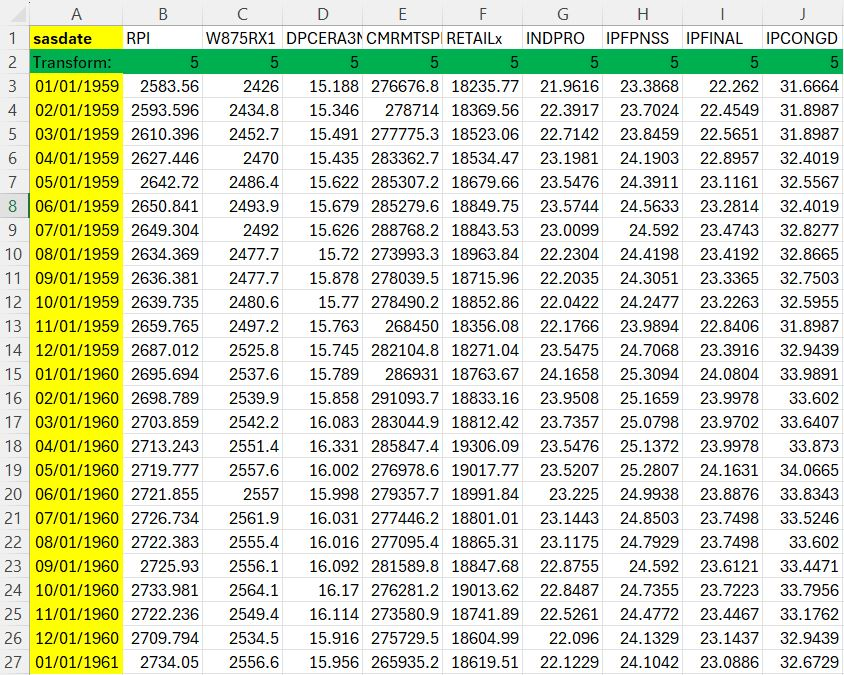

##### How can we handle this issue?

We can handle such issues by checking the **structure of the CSV file** and ensuring the date column is correctly identified and parsed:

1. **Examine the First Few Lines of the Dataset**: This helps understand if there are non-data rows that need to be skipped.
2. **Adjust the** pd.read_csv() **Call**: Specify the correct rows to skip or columns to use, based on the structure of your file.



[//]: # (-.- .tabset)

##### Checking the CSV Structure
Let's check the CSV structure by first trying to load the data without any date parsing:


In [112]:
# Load the dataset without parsing dates to inspect its structure
url = "https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv"
data = pd.read_csv(url)

# Print the first few and last few rows of the dataset
print("First 5 rows of the dataset:")
print(data.head(5))
print("\nLast 5 rows of the dataset:")
print(data.tail(5))


First 5 rows of the dataset:
      sasdate       RPI  W875RX1  DPCERA3M086SBEA    CMRMTSPLx      RETAILx  \
0  Transform:     5.000      5.0            5.000       5.0000      5.00000   
1    1/1/1959  2583.560   2426.0           15.188  276676.8154  18235.77392   
2    2/1/1959  2593.596   2434.8           15.346  278713.9773  18369.56308   
3    3/1/1959  2610.396   2452.7           15.491  277775.2539  18523.05762   
4    4/1/1959  2627.446   2470.0           15.435  283362.7075  18534.46600   

    INDPRO  IPFPNSS  IPFINAL  IPCONGD  ...  DNDGRG3M086SBEA  DSERRG3M086SBEA  \
0   5.0000   5.0000   5.0000   5.0000  ...            6.000            6.000   
1  21.9616  23.3868  22.2620  31.6664  ...           18.294           10.152   
2  22.3917  23.7024  22.4549  31.8987  ...           18.302           10.167   
3  22.7142  23.8459  22.5651  31.8987  ...           18.289           10.185   
4  23.1981  24.1903  22.8957  32.4019  ...           18.300           10.221   

   CES060000000

Look specifically for rows that do not contain data relevant to the analysis, such as headers or metadata. Once you identify these, you can adjust the loading procedure to skip them!

##### Updated Data Loading with Corrected Date Parsing

From the output in the previous tab, one can indicate that the row labelled "Transform:" in the dataset likely contains metadata rather than actual data. This row type usually provides information about the transformations or operations applied to the data in each column rather than the data values themselves. Such rows are unsuitable for direct analysis within the data set. They should typically be skipped when loading the data for analysis, as they can interfere with data parsing and processing. Skipping this row will ensure that the DataFrame contains only the numeric data needed for analysis, without any parsing errors from non-numeric rows.

In [118]:
import pandas as pd

# Load the dataset, specifying the skiprows parameter to skip the second row
url = "https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv"
data = pd.read_csv(url, skiprows=[1], parse_dates=['sasdate'], index_col='sasdate')

# Display the first two rows of the dataset
print("First two rows of the dataset:")
print(data.head(2))

First two rows of the dataset:
                 RPI  W875RX1  DPCERA3M086SBEA    CMRMTSPLx      RETAILx  \
sasdate                                                                    
1959-01-01  2583.560   2426.0           15.188  276676.8154  18235.77392   
1959-02-01  2593.596   2434.8           15.346  278713.9773  18369.56308   

             INDPRO  IPFPNSS  IPFINAL  IPCONGD  IPDCONGD  ...  \
sasdate                                                   ...   
1959-01-01  21.9616  23.3868  22.2620  31.6664   18.9498  ...   
1959-02-01  22.3917  23.7024  22.4549  31.8987   19.0492  ...   

            DNDGRG3M086SBEA  DSERRG3M086SBEA  CES0600000008  CES2000000008  \
sasdate                                                                      
1959-01-01           18.294           10.152           2.13           2.45   
1959-02-01           18.302           10.167           2.14           2.46   

            CES3000000008  UMCSENTx  DTCOLNVHFNM  DTCTHFNM   INVEST  VIXCLSx  
sasdate    

The `skiprows` parameter is used to skip rows at specific positions. Here, it skips the second row (index=1, as indexing starts from 0 in Python). This effectively ignores the row with `Transform:` and ensures that it does not interfere with the parsing of actual data rows. The `parse_dates` **and** `index_col` parameters are set to interpret the `sasdate` column as a datetime index, aiding in time-series analysis.

[//]: # (-.- .unlisted .unnumbered)

In addition to the series in the FRED-MD dataset we also wish to look at GDP. We use the series with id `GDPC1` from [FRED](https://fred.stlouisfed.org/series/GDPC1), an inflation-adjusted and seasonally adjusted real GDP measured in Billions of 2017 Dollars.

At this point we would need to import an aditional library:

In [128]:
# Import necessary libraries
from pandas_datareader import data as pdr  # # To download financial data directly from the FRED API

In [161]:
# Download U.S. Real GDP data from FRED
gdp_data = pdr.get_data_fred('GDPC1', start='1975-01-01', end='2019-12-31')

To fetch the data we can use the `pandas_datareader.get_data_fred` function to directly fetch the `GDPC1` series for the specified period from `FRED`.

### Restricting or subsetting time series data using Python

In Python, the process for restricting or subsetting time series data is typically handled using `pandas`, a powerful library designed for data manipulation and analysis. When working with time series in Python, the data is often managed as a `DataFrame` or `Series` object, with dates set as the index. This setup makes it straightforward to slice and subset the data based on date ranges or specific conditions. o restrict or subset your data based on specific time periods:

1. **Setting Date as Index**: Ensure that your time series data has dates set as the `DataFrame` index, which allows for efficient slicing and subsetting based on time periods.
2. **Subsetting Time Series**: You can directly use date strings to subset the data. For example, to restrict the data to a specific range, you can slice the `DataFrame` using date strings:

In [ ]:
# Restrict the time series to a specific range
restricted_data = data['1975-01-01':'2019-12-31']

3. **Learning Resources**: Unlike `R`, which has packages like `xts` that may require looking up specifics in cheatsheets, Python's `pandas` library uses consistent methods for indexing and subsetting across different types of data, making it easier to learn and apply. The official [pandas documentation](https://pandas.pydata.org/docs/) is an excellent resource for understanding and mastering these techniques. 

In our example, we can restrict the sample of the time-series data to be pre-Covid as follows:

In [157]:
# Fetch data
gdp_data = pdr.get_data_fred('GDPC1', start='1900-01-01', end='2020-12-31')

# Subset the data to be pre-Covid
pre_covid_gdp = gdp_data['1975-01-01':'2019-12-31']

Let's now proceed to a **logarithmic transformation** of the data. This procedure involves converting the GDP values to their logarithmic form to make percentage changes more apparent and easier to analyze.

In [151]:
# Apply logarithmic transformation to normalize the data
gdp_data['log_GDPC1'] = np.log(gdp_data['GDPC1'])

The gdp_data['GDPC1'] part accesses the 'GDPC1' column of the `gdp_data DataFrame`. The 'GDPC1' column contains the GDP values that are adjusted for inflation and seasonally adjusted, measured in billions of 2017 dollars. Then the `np.log()` function, from the `numpy` library, applies the natural logarithm to each value in the 'GDPC1' column.  

> Remember that the natural logarithm is a mathematical operation that transforms each number into its logarithm base e (approximately 2.71828). The logarithmic transformation is used here because it helps to linearize exponential data, stabilize variance, and make trends more apparent.

Lastly, the gdp_data['log_GDPC1']  part of the code creates a new column in the gdp_data DataFrame called 'log_GDPC1' and stores the results of the logarithmic transformation in this column. Essentially, it adds a new feature to the dataset, which represents the log-transformed GDP values.

Now, let's plot the series

In [265]:
# Plotting the log-transformed GDP data
gg = ggplot(gdp_data, aes('DATE', 'log_GDPC1')) + \
     geom_line(color='blue') + \
     ggtitle("Logarithmic Transformation of Real GDP") + \
     xlab("Year") + ylab("Log of GDP")
gg.show()

## ADF test

The Augmented Dickey-Fuller (ADF) test is a widely used statistical test in time-series analysis to check for stationarity, which is a key assumption in many econometric models. A stationary series has statistical properties, such as mean and variance, that do not change over time. The ADF test extends the Dickey-Fuller test by including lagged differences of the series to account for autocorrelation.
If you wish to apply the ADF (Augmented Dickey-Fuller) test to a series \(y\), the following regression is estimated:

$$\Delta y_t = \mu + \phi t + \psi y_{t-1} + \sum_{j=1}^p \theta_j \Delta y_{t-j} + w_t$$

Where:
- $\mu$ is a constant term,
- $\phi t$ accounts for a deterministic time trend (if included),
- $\psi$ tests for the presence of a unit root (stationarity),
- $\Delta y_{t-j}$ represents lagged differences and
- $w_t$ is a white noise error term.

The key parameter of interest is $\psi$:
- $\psi < 0$: The series $y$ is stationary.
- $\psi \geq 0$: The series $y$ is non-stationary.

The t-test statistic for \(\psi\) is calculated as:
$$t_{\psi} = \frac{\hat{\psi}}{se(\hat{\psi})}$$

We test the null hypothesis $H_0: \psi = 0$ (the series has a unit root and is non-stationary) against the alternative $H_A: \psi < 0$ (the series is stationary). The rejection of $H_0$ depends on critical values derived from the Dickey-Fuller distribution, which accounts for the presence of a constant and/or a trend in the regression.

Python's `statsmodels` library provides a robust implementation of the ADF test via the `adfuller()` function, making it straightforward to assess stationarity in a time-series dataset. Below, we apply the ADF test to a log-transformed GDP series, illustrating Python's capabilities for time-series analysis.

**1**. **Perform the ADF Test**

In [237]:
# Perform the ADF test on the log-transformed GDP series
adf_result = adfuller(gdp_data['log_GDPC1'], autolag='AIC')

The  `adfuller()` function from the `statsmodels.tsa.stattools` module performs the Augmented Dickey-Fuller test on the `gpd_data` time series to check for stationarity. In this example, we are using the gdp_data['log_GDPC1'] as input to the test, which is the log-transformed GDP series (log_GDPC1)- dependent variable being tested for stationarity. The `autolag='AIC'` parameter automatically selects the number of lagged difference terms (𝑝) to include in the regression based on the Akaike Information Criterion (AIC). Including lagged terms accounts for autocorrelation in the data and ensures the robustness of the test.

**2**. **Extract Results**

In [239]:
# Extract the results
adf_stat = adf_result[0]  # ADF statistic
p_value = adf_result[1]   # p-value
critical_values = adf_result[4]  # Critical values

The `adfuller()` function returns several values, which are stored in the adf_result object. These are unpacked into separate variables:

In [241]:
adf_stat = adf_result[0]  # ADF statistic

- The adf_result[0] represents the  ADF test statistic ($t_{\psi}$).
  - This statistic measures the likelihood that the series has a unit root (i.e., is non-stationary).
  - A smaller value (more negative) suggests stronger evidence against the null hypothesis of non-stationarity.

In [243]:
p_value = adf_result[1]  # p-value

- The adf_result[1] is the **p-value** of the test.
  - This indicates the probability of observing the test statistic under the null hypothesis  ($H_0: \psi = 0$).
  - A smaller p-value (e.g., < 0.05) indicates stronger evidence against the null hypothesis, suggesting the series is stationary.

In [245]:
critical_values = adf_result[4]  # Critical values

- The adf_result[4] is a dictionary containing the critical values for the test statistic at different significance levels (e.g., 1%, 5%, 10%).
  - These values compare the ADF statistic and determine whether to reject the null hypothesis.

**3**. **Print the Results**

In [247]:
print("ADF Test Results:")
print(f"ADF Statistic: {adf_stat}")
print(f"p-value: {p_value}")

ADF Test Results:
ADF Statistic: -1.5930116364842732
p-value: 0.4871030479066496


The `ADF Statistic` is the test statistic ($t_{\psi}$) value computed by the ADF test whereas the **p-value** here is the significance level of the test indicating the strength of evidence against the null hypothesis.

In [249]:
print("Critical Values:")
for key, value in critical_values.items():
    print(f"{key}: {value}")

Critical Values:
1%: -3.470126426071447
5%: -2.8790075987120027
10%: -2.5760826967621644


The output prints the critical values at various confidence levels (e.g., 1%, 5%, 10%). These values depend on the distribution of the test statistic and are not the same as standard t-distribution critical values.

##### What does the Python output tell us?

Let's begin by looking at the ADF statistic. In this example, it is equal to: 
$$ADF Statistic=−1.593$$
We must compare it against the critical values to determine if the null hypothesis ($H_0$) can be rejected. At the same time, the p-value is equal to:
$$p-value=0.487$$,
which indicates the probability of observing the test statistic under the null hypothesis. On the other hand, the critical values are:

- **1% level: −3.470**
- **5% level: −2.879**
- **10% level: −2.576**

##### How to interpret the results?

1. **Comparison of ADF Statistic with Critical Values**:
   - The ADF statistic (−1.593) is **greater than all critical values** (e.g., **−3.470**, **−2.879**, and **−2.576**).
   - This means the test statistic does not fall into the rejection region for any significance level (1%, 5%, or 10%)
2. **p-value**:
   - The p-value (0.487) is **much greater than 0.05** (the typical threshold for significance).
   - This indicates insufficient evidence to reject the null hypothesis.

Therefore, we fail to reject the null hypothesis since the ADF statistic is not smaller than the critical values and the p-value is high. This means that the series **log_GDPC1** is **non-stationary**! 

### Including Deterministic Terms in Python's ADF Test

The ADF test implemented in Python via the `adfuller` function from the statsmodels library includes options for handling deterministic terms such as:

- A constant (intercept), and
- A linear time trend.

The `adfuller` function provides control over which deterministic terms to include using the regression parameter. This parameter allows you to specify the type of deterministic terms to be included in the test:

- 'c': Constant only.
- 'ct': Constant and linear trend.
- 'ctt': Constant, linear trend, and quadratic trend.
- 'nc': No constant or trend.

For example, to replicate the ADF test with both a **constant** and a **linear trend**, you would use:

In [282]:
# ADF test with a deterministic time trend (regression='ct')
adf_result_with_trend = adfuller(gdp_data['log_GDPC1'], regression='ct', autolag='AIC')

> Unlike R's `adf.test` function (which automatically includes a constant and trend), Python gives you explicit control over the choice of deterministic terms, making it more flexible for advanced users. This flexibility allows you to tailor the ADF test to match the specific requirements of your analysis, such as testing different null hypotheses about the presence of a unit root under various deterministic assumptions.

> If more advanced unit root testing is required, Python offers additional libraries like `arch` or `statsmodels` URCA equivalents (e.g., `KPSS` tests) to handle these scenarios.

In [284]:
# Extract and print results for the test with a time trend
print("ADF Test Results with Time Trend:")
print(f"ADF Statistic: {adf_result_with_trend[0]}")
print(f"p-value: {adf_result_with_trend[1]}")
print("Critical Values:")
for key, value in adf_result_with_trend[4].items():
    print(f"{key}: {value}")

ADF Test Results with Time Trend:
ADF Statistic: -1.3039244028908727
p-value: 0.8869550406947029
Critical Values:
1%: -4.014028310565215
5%: -3.437113561282183
10%: -3.142678176412781


At this point let's analyze and compare the results of the ADF test with a **deterministic trend** and the **initial** ADF test (which included only a constant). The table below summarises the key takeaways:

| **Test Type**              | **ADF Statistic** | **p-value** | **Critical Value (1%)** | **Critical Value (5%)** | **Critical Value (10%)** | **Conclusion**                     |
|----------------------------|-------------------|-------------|-------------------------|-------------------------|--------------------------|-------------------------------------|
| With **Deterministic Trend**   | -1.3039          | 0.8869      | -4.0140                | -3.4371                | -3.1427                 | Fail to reject $H_0$ (Non-stationary) |
| With Constant Only         | -1.5930          | 0.4871      | -3.4701                | -2.8790                | -2.5761                 | Fail to reject $H_0$ (Non-stationary) |


By comparing the results of each ADF test one could argue that:
- **ADF Statistic**: The test statistic is less negative in the test with a deterministic trend, indicating weaker evidence against the null hypothesis.
- **p-value**: The p-value is higher with a deterministic trend, further confirming the series is non-stationary in both cases.
- **Critical Values**: Including a trend introduces stricter critical thresholds, making it harder to reject the null hypothesis.

### Stationarity Without a Time Trend

When analyzing GDP, stationarity around a constant time trend may not be a plausible assumption. GDP often exhibits long-term growth patterns that make it unrealistic to assume that deviations from the trend will return to a fixed level. As a result, we may want to repeat the ADF test without including a time trend in the regression.

In Python, this can be achieved by setting the `regression` parameter in the adfuller function to `'c'`, which includes only a **constant** term (intercept) and excludes a time trend:

In [292]:
adf_result_no_trend = adfuller(gdp_data['log_GDPC1'], regression='c', autolag='AIC')

By excluding the time trend, the ADF test evaluates whether the series is stationary around a constant mean, which might be a more reasonable assumption for GDP, particularly if you believe that deviations from the mean are due to short-term fluctuations rather than systematic growth over time.

In [294]:
# Extract and print results for the test without a time trend
print("\nADF Test Results without Time Trend:")
print(f"ADF Statistic: {adf_result_no_trend[0]}")
print(f"p-value: {adf_result_no_trend[1]}")
print("Critical Values:")
for key, value in adf_result_no_trend[4].items():
    print(f"{key}: {value}")


ADF Test Results without Time Trend:
ADF Statistic: -1.5930116364842732
p-value: 0.4871030479066496
Critical Values:
1%: -3.470126426071447
5%: -2.8790075987120027
10%: -2.5760826967621644


By comparing the results we can conclude that:

| **Test Type**              | **ADF Statistic** | **p-value** | **Critical Value (1%)** | **Critical Value (5%)** | **Critical Value (10%)** | **Conclusion**                     |
|----------------------------|-------------------|-------------|-------------------------|-------------------------|--------------------------|-------------------------------------|
| With Deterministic Trend   | -1.3039          | 0.8869      | -4.0140                | -3.4371                | -3.1427                 | Fail to reject $H_0$ (Non-stationary) |
| With Constant Only         | -1.5930          | 0.4871      | -3.4701                | -2.8790                | -2.5761                 | Fail to reject $H_0$ (Non-stationary) |
| **Without Time Trend**         | -1.5930          | 0.4871      | -3.4701                | -2.8790                | -2.5761                 | Fail to reject $H_0$ (Non-stationary) |


1. **Non-Stationarity Across All Configurations**:

- In all three cases, the null hypothesis ($H_0$ : The series has a unit root) **cannot be rejected** at any conventional significance level (1%, 5%, or 10%).
- This indicates that the log-transformed GDP series (**log_GDPC1**) is **non-stationary** regardless of whether a deterministic trend, a constant, or neither is included in the regression.

2. **Effect of Including a Deterministic Trend**:

   Including a deterministic trend (regression=’ct’) weakens evidence against non-stationarity:
    - The **ADF Statistic** is less negative (**−1.3039**) compared to the other configurations (**−1.5930**).
    - The **p-value** is much higher (**0.8869**), further reducing evidence to reject $H_0$.
    - The critical values are more stringent, reflecting the additional complexity of including a trend.

4. **Constant vs. No Time Trend**:
- The results for "With Constant Only" and "Without Time Trend" are identical, as these configurations test the same hypothesis (stationarity around a constant mean).
- This reinforces the robustness of the conclusion that the series is non-stationary in both cases.

### What are the next steps for analysis?

Since we conclude that the series log_GDPC1 is certainly not stationary ($I(0)$), the next step is to determine whether it is $I(1)$ (stationary after first differencing) or $I(2)$ (stationary after second differencing). This can be done by applying the same ADF test to the first difference of the series, Δlog_GDPC1.

In [324]:
# Compute the first difference of log_GDPC1
gdp_data['diff_log_GDPC1'] = gdp_data['log_GDPC1'].diff()

# Remove the first observation (NA) created by differencing
dy = gdp_data[['DATE', 'diff_log_GDPC1']].dropna()

# Convert the DATE column to string for lets_plot compatibility
dy['DATE'] = dy['DATE'].astype(str)

# Plotting the first difference of log-transformed GDP
gg = ggplot(dy, aes('DATE', 'diff_log_GDPC1')) + \
     geom_line(color='blue') + \
     ggtitle("First Difference of Log GDP (Δlog_GDPC1)") + \
     xlab("Year") + ylab("Δlog_GDPC1")
gg.show()

#### Step 1: Compute the First Difference of the Log-Transformed GDP

The `gdp_data['log_GDPC1']` refers to the log-transformed GDP series already stored in the DataFrame. The `diff()` function calculates the difference between each value and the previous one in the series:
- Formula: $\Delta y_t = y_t - y_{t-1}$
- Example: Consider a time series where at time $t$, $(y_t = 2.5)$ and at time $(t-1)$, $(y_{t-1} = 2.3)$, then $\Delta y_t = 2.5 - 2.3 = 0.2$.

Then the `gdp_data['diff_log_GDPC1']` creates a new column in the DataFrame to store the **first differences**.

> Taking the first difference removes trends and makes the series stationary if it is **$𝐼(1)$** (integrated of order 1). This step is essential for applying time-series models like ARIMA, which require stationarity.

#### Step 2: Remove Missing Values

In [ ]:
dy = gdp_data[['DATE', 'diff_log_GDPC1']].dropna()

Here, we select only the `DATE` and `diff_log_GDPC1` columns for analysis. Then we use the `dropna()` function which removes the firdt row, which is NA (Not Available) because the first difference **cannot be computed for the very first observation**.

> Right now, you might be wondering ***why remove missing values?*** Remember that after first differencing, the first observation does not have a previous value to subtract from, resulting in an NA. Removing this row ensures that the series is clean and ready for further analysis and visualization.

#### Step 3: **Convert** DATE **to String**

In [ ]:
dy['DATE'] = dy['DATE'].astype(str)

The `dy['DATE']:` refers to the `DATE` column, which contains the time index of the GDP series. We use the `astype(str):` function to convert the `DATE` column from `datetime64` format to `string` format.

> Right now, you might be wondering *** why convert to String?***. It is important to note that the `lets-plot` library requires categorical or string values for the x-axis when plotting, as it **does not natively** handle `datetime64` types. Converting `DATE` to string ensures compatibility with the plotting functions.

#### Step 4: Plot the First Differenced Series

In [ ]:
gg = ggplot(dy, aes('DATE', 'diff_log_GDPC1')) + \
     geom_line(color='blue') + \
     ggtitle("First Difference of Log GDP (Δlog_GDPC1)") + \
     xlab("Year") + ylab("Δlog_GDPC1")

If the plot appears to fluctuate around a mean level with **no clear trend or drift**, the series is likely **stationary**. In our example, Judging by the plot for the first-differenced series `(Δlog_GDPC1)`, there seems to be **no significant drift or trend**. The series fluctuates around a mean of approximately zero, with no obvious upward or downward trend over time. Hence, **we will not include any deterministic term** (such as a constant or time trend) into the ADF regression when testing for stationarity.

#### ADF Test on the first differenced series without detrministic term

In [348]:
# Perform the ADF test on the first differenced series without deterministic terms
adf_result_no_drift = adfuller(dy['diff_log_GDPC1'], regression='n', autolag='BIC')

# Extract and print results
print("ADF Test on First Differenced Series (No Deterministic Terms):")
print(f"ADF Statistic: {adf_result_no_drift[0]}")
print(f"p-value: {adf_result_no_drift[1]}")
print("Critical Values:")
for key, value in adf_result_no_drift[4].items():
    print(f"{key}: {value}")

ADF Test on First Differenced Series (No Deterministic Terms):
ADF Statistic: -4.212455739256815
p-value: 3.125321620043741e-05
Critical Values:
1%: -2.5784874097481567
5%: -1.9426192919936818
10%: -1.6154014900113305


Note here that we need to specify `regression='n'` to make sure that no deterministic terms ( neither a constant nor a trend) are included in the regression equation. This corresponds to testing for stationarity around zero (no drift or trend). The `autolag='BIC'` automatically selects the optimal number of lagged differences ($p$) in the regression based on the Bayesian Information Criterion (BIC). BIC penalizes more complex models, favoring simpler ones when possible.

Based on the results of the Augmented Dickey-Fuller (ADF) test, we reject the null hypothesis that the first-differenced series, 
`Δlog_GDPC1`, has a unit root, as the ADF statistic (-4.2125) is smaller than the critical value at the 1% significance level (-2.58). This indicates that the first-differenced series is stationary ($I(0)$). Consequently, this implies that the original log-transformed GDP series, `log_GDPC1`, is integrated of order one ($I(1)$), meaning it becomes stationary after first differencing. 

## Revisiting FRED-MD stationarity properties

Let us now return to the data series included in the FRED-MD dataset, which we have already loaded into the `fred_md` DataFrame. To obtain detailed information about the variables in the dataset, we can use `pandas`' built-in methods such as `info()` for metadata and `describe()` for summary statistics.


In [359]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from lets_plot import *
import numpy as np

LetsPlot.setup_html()

# Load the dataset (skip metadata rows)
url = "https://files.stlouisfed.org/files/htdocs/fred-md/monthly/current.csv"
fred_md = pd.read_csv(url, skiprows=range(1, 2), parse_dates=['sasdate'], index_col='sasdate')

This code loads the `FRED-MD` dataset, a monthly collection of macroeconomic time-series data, directly from its online source into a `pandas` DataFrame. It skips metadata rows to ensure the data is clean, parses the `sasdate` column as dates for time-series operations, and sets it as the index for efficient time-based analysis. This preparation is essential for subsequent tasks like exploring stationarity, visualizing trends, and applying statistical tests

In [362]:
# Get detailed information about the dataset
print("\nDetailed Information About Variables:")
fred_md.info()

# Get summary statistics of the dataset
print("\nSummary Statistics of the Variables:")
print(fred_md.describe())

# Display the list of variable names in the dataset
print("\nVariable Names in the Dataset:")
print(fred_md.columns.tolist())


Detailed Information About Variables:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 789 entries, 1959-01-01 to 2024-09-01
Columns: 126 entries, RPI to VIXCLSx
dtypes: float64(102), int64(24)
memory usage: 782.8 KB

Summary Statistics of the Variables:
                RPI       W875RX1  DPCERA3M086SBEA     CMRMTSPLx  \
count    789.000000    789.000000       789.000000  7.880000e+02   
mean    9532.882349   8120.457541        56.443696  8.216333e+05   
std     5034.777536   3987.690712        30.493997  3.834359e+05   
min     2583.560000   2426.000000        15.188000  2.659352e+05   
25%     5146.807000   4573.100000        28.918000  4.880104e+05   
50%     8296.928000   7261.700000        48.297000  7.194803e+05   
75%    13762.240000  11441.600000        84.127000  1.173491e+06   
max    22850.332000  16426.800000       121.579000  1.530114e+06   

             RETAILx      INDPRO     IPFPNSS     IPFINAL     IPCONGD  \
count     789.000000  789.000000  789.000000  789.00000

This code provides a comprehensive overview of the FRED-MD dataset. The `info()` method displays metadata such as variable names, data types, and non-null counts, offering insights into the dataset's structure. The `describe()` method computes summary statistics (e.g., mean, standard deviation, min, max) for all numerical variables, helping identify patterns and anomalies. Finally, the `columns.tolist()` method lists all variable names, making it easier to identify the available data series for analysis.

### Industrial Production
Let's look at the variable describing industrial production.

In [366]:
# Select the "INDPRO" variable
indpro = fred_md['INDPRO']

# Display the first few rows of INDPRO
print("Industrial Production (INDPRO) Head:")
print(indpro.head())

Industrial Production (INDPRO) Head:
sasdate
1959-01-01    21.9616
1959-02-01    22.3917
1959-03-01    22.7142
1959-04-01    23.1981
1959-05-01    23.5476
Name: INDPRO, dtype: float64


In the context of the `FRED-MD` dataset, the transformation type for the INDPRO variable is equivalent to the first difference of its natural logarithm: $ln(𝑥)−ln(𝑥−1)$. This transformation stabilizes the variance and removes trends, making the series stationary. This is consistent with our earlier findings for GDP, where the log-transformed series was $I(1)$ (non-stationary), and its first difference was $I(0)$ (stationary). Similarly, we expect `diff(log(INDPRO))` to be $I(0)$ and `log(INDPRO)` to be $I(1)$.


In [373]:
# Log-transform the INDPRO variable
y = np.log(indpro)

# Compute the first difference of the log-transformed series
dy = y.diff().dropna()

# Prepare data for plotting the log-transformed series
plot_y = pd.DataFrame({
    'DATE': y.index.astype(str),
    'log_INDPRO': y
}).reset_index(drop=True)

# Plot the log-transformed series
gg_y = ggplot(plot_y, aes(x='DATE', y='log_INDPRO')) + \
       geom_line(color='blue') + \
       ggtitle("Log-Transformed Industrial Production (INDPRO)") + \
       xlab("Date") + ylab("log(INDPRO)")
gg_y.show()

In [375]:
# Prepare data for plotting the first-differenced series
plot_dy = pd.DataFrame({
    'DATE': dy.index.astype(str),
    'diff_log_INDPRO': dy
}).reset_index(drop=True)

# Plot the first-differenced series
gg_dy = ggplot(plot_dy, aes(x='DATE', y='diff_log_INDPRO')) + \
        geom_line(color='green') + \
        ggtitle("First Difference of Log-Transformed Industrial Production") + \
        xlab("Date") + ylab("Δlog(INDPRO)")
gg_dy.show()

Currently, we are analyzing the entire available dataset in our study. However, it might be beneficial to consider refining the sample size to determine how it affects the conclusions. For instance, excluding data from the COVID-19 period could provide insights into the impact of this specific event on the dataset’s trends. Let’s proceed by conducting the Augmented Dickey-Fuller (ADF) tests using Python to assess the stationarity of our time series data, which will help in further understanding the dynamics of our dataset under different conditions.

In [378]:
# Restrict the sample by excluding the COVID-19 period (2020 onwards)
restricted_dy = dy.loc[:'2019-12-31']

# Display the head of the restricted series
print("Restricted First Difference of Log-Transformed INDPRO:")
print(restricted_dy.head())

Restricted First Difference of Log-Transformed INDPRO:
sasdate
1959-02-01    0.019395
1959-03-01    0.014300
1959-04-01    0.021080
1959-05-01    0.014954
1959-06-01    0.001137
Name: INDPRO, dtype: float64


Then we can perform the ADF test

In [381]:
# Perform the ADF test on the restricted series (no deterministic terms)
adf_result_restricted = adfuller(restricted_dy, regression='n', autolag='BIC')

# Display ADF test results
print("\nADF Test Results for Restricted Sample (No Deterministic Terms):")
print(f"ADF Statistic: {adf_result_restricted[0]}")
print(f"p-value: {adf_result_restricted[1]}")
print("Critical Values:")
for key, value in adf_result_restricted[4].items():
    print(f"  {key}: {value}")

if adf_result_restricted[0] < adf_result_restricted[4]['1%']:
    print("Conclusion: The restricted first-differenced series is stationary (I(0)).")
else:
    print("Conclusion: The restricted first-differenced series is non-stationary.")


ADF Test Results for Restricted Sample (No Deterministic Terms):
ADF Statistic: -9.575483380761701
p-value: 8.713404479004726e-17
Critical Values:
  1%: -2.568822240709592
  5%: -1.9413757490171204
  10%: -1.616459731994681
Conclusion: The restricted first-differenced series is stationary (I(0)).


**Conclusion**:
- The first-differenced log-transformed INDPRO series for the restricted sample (excluding the COVID-19 period) is stationary ($I(0)$).
- This aligns with expectations for a first-differenced economic time series.
- Excluding the COVID-19 period does not change the conclusion that `Δln(INDPRO)` is stationary, reinforcing the robustness of the result.

In [386]:
# Perform the ADF test on the log-transformed INDPRO series with a time trend
adf_result_with_trend = adfuller(y.dropna(), regression='ct', autolag='BIC')

# Display the ADF test results
print("\nADF Test Results for Log-Transformed INDPRO (With Time Trend):")
print(f"ADF Statistic: {adf_result_with_trend[0]}")
print(f"p-value: {adf_result_with_trend[1]}")
print("Critical Values:")
for key, value in adf_result_with_trend[4].items():
    print(f"  {key}: {value}")

if adf_result_with_trend[0] < adf_result_with_trend[4]['1%']:
    print("Conclusion: The log-transformed INDPRO series is stationary (I(0)) with a time trend.")
else:
    print("Conclusion: The log-transformed INDPRO series is non-stationary with a time trend.")


ADF Test Results for Log-Transformed INDPRO (With Time Trend):
ADF Statistic: -1.5566955092850743
p-value: 0.8089306548244729
Critical Values:
  1%: -3.970319477232129
  5%: -3.416083335240194
  10%: -3.1303417705553604
Conclusion: The log-transformed INDPRO series is non-stationary with a time trend.


The ADF test statistic for `log(INDPRO)` with a time trend is **−1.5567**, which is **not smaller than any of the critical values** at 1%, 5%, or 10% significance levels. This means we fail to reject the null hypothesis that the series has a unit root. While the p-value (**0.8089**) is also very high, confirming the null hypothesis, we conclude that `log(INDPRO)` is non-stationary ($I(1)$).

> At this point, it is essential to note that the conclusions from the ADF test are not always definitive. A test statistic close to critical values can lead to ambiguity in interpretation, especially when results are sensitive to lag selection or time periods. Moreover, The stationarity of `Δlog(INDPRO)` suggests that changes in industrial production growth rates are stable, even though the level series (`log(INDPRO)`) exhibits non-stationarity.

### Corporate bond rates 
Let's have a look at the different transformation types associated to the time-series in FRED-MD.

> In Python, we don't have predefined transformation metadata (`ttype` in R). Instead, you can create a dictionary mapping transformations to variable names based on external metadata or analysis.

In [394]:
# Simulated metadata for transformation types (mocked for example purposes)
transformation_metadata = {
    "First difference of natural log": ["RPI", "INDPRO"],
    "First difference": ["UNRATE", "PAYEMS"],
    "Level (i.e., no transformation)": ["AAAFFM", "CES0600000007", "AWHMAN"],
    "Natural log": ["M1SL", "M2SL"],
    "Second difference of natural log": ["DNDGRG3M086SBEA"],
    "First difference of percent change": ["COMPAPFFx"],
}

# List the unique transformation types
print("Unique Transformation Types:")
for key in transformation_metadata.keys():
    print(f"- {key}")

Unique Transformation Types:
- First difference of natural log
- First difference
- Level (i.e., no transformation)
- Natural log
- Second difference of natural log
- First difference of percent change


Let's identify variables with **no transformation**.

In [397]:
# Identify variables with "Level (i.e., no transformation)"
level_variables = transformation_metadata["Level (i.e., no transformation)"]

# Display the variables
print("\nVariables with No Transformation (Level):")
print(level_variables)


Variables with No Transformation (Level):
['AAAFFM', 'CES0600000007', 'AWHMAN']


Let's pick the `AAAFFM` series. The `AAAFFM` series is extracted for further analysis, as it does not require transformation and is expected to be **stationary**.

In [402]:
# Extract the AAAFFM series
aaaffm = fred_md['AAAFFM']

# Display the first few rows of AAAFFM
print("\nAAAFFM Series Head:")
print(aaaffm.head())


AAAFFM Series Head:
sasdate
1959-01-01    1.64
1959-02-01    1.71
1959-03-01    1.33
1959-04-01    1.27
1959-05-01    1.47
Name: AAAFFM, dtype: float64


The `AAAFFM` variable represents the difference between the corporate bond rate for AAA-rated companies and the federal funds rate. Let's pplot the `AAAFFM` series:

In [408]:
# Prepare data for plotting
plot_data = pd.DataFrame({
    'Date': aaaffm.index.astype(str),  # Convert index to string for compatibility
    'AAAFFM': aaaffm
}).dropna()  # Drop any missing values for clean plotting

# Create a simple line plot
gg = ggplot(plot_data, aes(x='Date', y='AAAFFM')) + \
     geom_line(color='blue') + \
     ggtitle("AAAFFM: Moody's AAA Corporate Bond Minus FEDFUNDS Rate") + \
     xlab("Date") + ylab("AAAFFM")

# Display the plot
gg.show()

Given the transformation (or in this case absence of transformation) we should find this series to be stationary, $I(0)$. As you already know by now, in Python you can perform the Augmented Dickey-Fuller (ADF) test using the `adfuller` function from the `statsmodels` library. To test whether the `AAAFFM` series is stationary ($I(0)$) we include a constant (drift) in the ADF regression, which corresponds to `type = "drift"` in R. 

In [412]:
# Perform the ADF test on the AAAFFM series with drift (constant term)
adf_result_aaa = adfuller(aaaffm.dropna(), regression='c', autolag='BIC')

# Display the ADF test results
print("\nADF Test Results for AAAFFM Series (With Drift):")
print(f"ADF Statistic: {adf_result_aaa[0]}")
print(f"p-value: {adf_result_aaa[1]}")
print("Critical Values:")
for key, value in adf_result_aaa[4].items():
    print(f"  {key}: {value}")

if adf_result_aaa[0] < adf_result_aaa[4]['1%']:
    print("Conclusion: The AAAFFM series is stationary (I(0)) at the 1% significance level.")
elif adf_result_aaa[0] < adf_result_aaa[4]['5%']:
    print("Conclusion: The AAAFFM series is stationary (I(0)) at the 5% significance level.")
elif adf_result_aaa[0] < adf_result_aaa[4]['10%']:
    print("Conclusion: The AAAFFM series is stationary (I(0)) at the 10% significance level.")
else:
    print("Conclusion: The AAAFFM series is non-stationary.")



ADF Test Results for AAAFFM Series (With Drift):
ADF Statistic: -4.122213492466828
p-value: 0.0008898035741166508
Critical Values:
  1%: -3.438697054464251
  5%: -2.8652241623148678
  10%: -2.5687317987167284
Conclusion: The AAAFFM series is stationary (I(0)) at the 1% significance level.


The ADF test results confirm that the AAAFFM series is stationary $I(0)$ at the 1% significance level, as the ADF statistic (**-4.1222**) is **smaller** than the critical value (**-3.4387**) and the p-value (**0.00089**) is below 0.01. This indicates that the series does not exhibit a unit root and is inherently stable, fluctuating around a mean without long-term trends. As a result, no transformations such as differencing or logarithms are required, and the series can be directly used in time-series analysis or modeling.

### Oil prices
Next we chose a series which, according to the FRED-MD guidance, requires differencing twice to achieve stationarity. We don't have a built-in equivalent to the `var.info` structure from R's FRED-MD tools in Python. However, we can simulate the logic by maintaining a manual dictionary or metadata structure that mimics `ttype` and `fred`. 

In [417]:
# Simulated metadata for transformation types (mock example)
transformation_metadata = {
    "Second difference of natural log: (ln(x)-ln(x-1))-(ln(x-1)-ln(x-2))": [
        "M1SL", "M2SL", "TOTRESNS", "BUSLOANS", "REALLN", "NONREVSL", 
        "WPSFD49207", "WPSFD49502", "WPSID61", "WPSID62", "OILPRICEx", 
        "PPICMM", "CPIAUCSL", "CPIAPPSL", "CPITRNSL", "CPIMEDSL", 
        "CUSR0000SAC", "CUSR0000SAD", "CUSR0000SAS", "CPIULFSL", 
        "CUSR0000SA0L2", "CUSR0000SA0L5", "PCEPI", "DDURRG3M086SBEA", 
        "DNDGRG3M086SBEA", "DSERRG3M086SBEA", "CES0600000008", 
        "CES2000000008", "CES3000000008", "DTCOLNVHFNM", "DTCTHFNM", 
        "INVEST"
    ]
}

# List all series requiring second differencing of natural log
series_requiring_second_differencing = transformation_metadata[
    "Second difference of natural log: (ln(x)-ln(x-1))-(ln(x-1)-ln(x-2))"
]

# Display the series
print("Series Requiring Second Differencing of Natural Log:")
print(series_requiring_second_differencing)


Series Requiring Second Differencing of Natural Log:
['M1SL', 'M2SL', 'TOTRESNS', 'BUSLOANS', 'REALLN', 'NONREVSL', 'WPSFD49207', 'WPSFD49502', 'WPSID61', 'WPSID62', 'OILPRICEx', 'PPICMM', 'CPIAUCSL', 'CPIAPPSL', 'CPITRNSL', 'CPIMEDSL', 'CUSR0000SAC', 'CUSR0000SAD', 'CUSR0000SAS', 'CPIULFSL', 'CUSR0000SA0L2', 'CUSR0000SA0L5', 'PCEPI', 'DDURRG3M086SBEA', 'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008', 'CES3000000008', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST']


You can see that there are many. Let's select `OILPRICEx`, which measures the oil price.

In [423]:
# Extract the OILPRICEx series
oil_prices = fred_md['OILPRICEx']

# Display the first few rows of the OILPRICEx series
print("\nOILPRICEx Series Head:")
print(oil_prices.head())



OILPRICEx Series Head:
sasdate
1959-01-01    3.00
1959-02-01    3.00
1959-03-01    2.97
1959-04-01    2.97
1959-05-01    2.97
Name: OILPRICEx, dtype: float64


The `OILPRICEx` represents oil prices and according to FRED-MD guidance, it requires second differencing of the natural log to achieve stationarity.

In [426]:
# Extract the OILPRICEx series and drop missing values
oil_prices = fred_md['OILPRICEx'].dropna()

# Log-transformation
log_oil_prices = np.log(oil_prices)

# First difference of the log-transformed series
first_diff_log_oil_prices = log_oil_prices.diff().dropna()

# Second difference of the log-transformed series
second_diff_log_oil_prices = first_diff_log_oil_prices.diff().dropna()


#### Different Plots for the `OILPRICEx` variable

[//]: # (-.- .tabset)

##### Plot Log-Transformed `OILPRICEx`

In [431]:
# Prepare data for the plot
log_plot_data = pd.DataFrame({
    'Date': log_oil_prices.index.astype(str),
    'Log_OILPRICEx': log_oil_prices
}).reset_index(drop=True)

# Create the plot
gg_log = ggplot(log_plot_data, aes(x='Date', y='Log_OILPRICEx')) + \
         geom_line(color='blue') + \
         ggtitle("Log-Transformed OILPRICEx") + \
         xlab("Date") + ylab("log(OILPRICEx)")
gg_log.show()

##### Plot First Difference

In [436]:
# Prepare data for the plot
first_diff_plot_data = pd.DataFrame({
    'Date': first_diff_log_oil_prices.index.astype(str),
    'First_Diff_Log_OILPRICEx': first_diff_log_oil_prices
}).reset_index(drop=True)

# Create the plot
gg_first_diff = ggplot(first_diff_plot_data, aes(x='Date', y='First_Diff_Log_OILPRICEx')) + \
                geom_line(color='green') + \
                ggtitle("First Difference of Log-Transformed OILPRICEx") + \
                xlab("Date") + ylab("Δlog(OILPRICEx)")
gg_first_diff.show()

##### Plot Second Difference

In [441]:
# Prepare data for the plot
second_diff_plot_data = pd.DataFrame({
    'Date': second_diff_log_oil_prices.index.astype(str),
    'Second_Diff_Log_OILPRICEx': second_diff_log_oil_prices
}).reset_index(drop=True)

# Create the plot
gg_second_diff = ggplot(second_diff_plot_data, aes(x='Date', y='Second_Diff_Log_OILPRICEx')) + \
                 geom_line(color='red') + \
                 ggtitle("Second Difference of Log-Transformed OILPRICEx") + \
                 xlab("Date") + ylab("Δ²log(OILPRICEx)")
gg_second_diff.show()

[//]: # (-.- .unlisted .unnumbered)

The first thing you notice when looking at these plots is that until 1980 oil prices moved in distinct discrete steps, mainly determined by OPEC. From 1980 onwards there are more continuous price changes. So, let's restrict the series to start in 1981.

In [448]:
# Restrict the log-transformed OILPRICEx series to start from 1981
log_oil_prices_restricted = log_oil_prices['1981-01-01':'2024-09-01']

# First and second differences of the restricted series
first_diff_log_oil_prices_restricted = log_oil_prices_restricted.diff().dropna()
second_diff_log_oil_prices_restricted = first_diff_log_oil_prices_restricted.diff().dropna()

# Display the first few rows of the restricted series
print("\nRestricted Log OILPRICEx (Post-1980):")
print(log_oil_prices_restricted.head())



Restricted Log OILPRICEx (Post-1980):
sasdate
1981-01-01    3.637586
1981-02-01    3.637586
1981-03-01    3.637586
1981-04-01    3.637586
1981-05-01    3.637586
Name: OILPRICEx, dtype: float64


Let's now plot the restricted series and differences

In [453]:
import matplotlib.pyplot as plt
from lets_plot import *
LetsPlot.setup_html()

# Prepare data for each plot
log_plot_data = pd.DataFrame({
    'Date': log_oil_prices_restricted.index.astype(str),
    'Log_OILPRICEx': log_oil_prices_restricted
}).reset_index(drop=True)

first_diff_plot_data = pd.DataFrame({
    'Date': first_diff_log_oil_prices_restricted.index.astype(str),
    'First_Diff_Log_OILPRICEx': first_diff_log_oil_prices_restricted
}).reset_index(drop=True)

second_diff_plot_data = pd.DataFrame({
    'Date': second_diff_log_oil_prices_restricted.index.astype(str),
    'Second_Diff_Log_OILPRICEx': second_diff_log_oil_prices_restricted
}).reset_index(drop=True)

# Create individual plots
plot1 = ggplot(log_plot_data, aes(x='Date', y='Log_OILPRICEx')) + \
        geom_line(color='blue') + \
        ggtitle("Restricted Log OILPRICEx (Post-1980)") + \
        xlab("Date") + ylab("log(OILPRICEx)")

plot2 = ggplot(first_diff_plot_data, aes(x='Date', y='First_Diff_Log_OILPRICEx')) + \
        geom_line(color='green') + \
        ggtitle("First Difference of Restricted Log OILPRICEx") + \
        xlab("Date") + ylab("Δlog(OILPRICEx)")

plot3 = ggplot(second_diff_plot_data, aes(x='Date', y='Second_Diff_Log_OILPRICEx')) + \
        geom_line(color='red') + \
        ggtitle("Second Difference of Restricted Log OILPRICEx") + \
        xlab("Date") + ylab("Δ²log(OILPRICEx)")

# Display plots separately
plot1.show()
plot2.show()
plot3.show()


By running the abive code one could indicate that three key functions are used: 

- `aes()`, which maps data columns to visual elements (e.g., `Date` to the x-axis and transformed values to the y-axis),
- `geom_line()`, which generates line plots to represent changes in the series, and
- `ggtitle()`, `xlab()`, and `ylab()`, which add titles and axis labels for clarity.
 
The code creates separate plots for the **log-transformed**, **first difference**, and **second difference** of oil prices, displaying them individually. While **Lets-Plot** handles aesthetics and plotting, **Matplotlib** can integrate these visuals into a combined layout if needed, offering flexibility and control for advanced visualizations.

Just looking at the plots we would certainly entertain the possibility that `log(OILPRICEx)` could be $I(1)$: 

1. **Log-transformed OILPRICEx plot**:
   - The first plot shows a clear upward trend, with fluctuations that appear persistent over time.
   - This indicates that the log-transformed series might not be stationary in its current form, as it exhibits non-random trends.
2. **First Difference of log(OILPRICEx)**:
   - The second plot shows that differencing removes the trend from the original series, resulting in fluctuations that appear more stationary.
   - This suggests that the first-differenced series could be stationary ($I(0)$).
3. **Second Difference of log(OILPRICEx)**:
   - The third plot shows the second differences of the log-transformed series, with even more stabilization.
   - However, the first differences (second plot) already appear sufficient to achieve stationarity, indicating the series is likely $I(1)$.

Let's run the ADF test

In [460]:
from statsmodels.tsa.stattools import adfuller

# Perform the ADF test for the log-transformed OILPRICEx series (with drift)
adf_oil = adfuller(log_oil_prices_restricted.dropna(), regression='c', autolag='BIC')

# Perform the ADF test for the first difference of log(OILPRICEx) (with drift)
adf_doil = adfuller(first_diff_log_oil_prices_restricted.dropna(), regression='c', autolag='BIC')

# Perform the ADF test for the second difference of log(OILPRICEx) (with drift)
adf_d2oil = adfuller(second_diff_log_oil_prices_restricted.dropna(), regression='c', autolag='BIC')

# Function to display ADF results
def display_adf_results(adf_result, title):
    print(f"ADF Test Results for {title}:")
    print(f"ADF Statistic: {adf_result[0]}")
    print(f"p-value: {adf_result[1]}")
    print("Critical Values:")
    for key, value in adf_result[4].items():
        print(f"  {key}: {value}")
    if adf_result[0] < adf_result[4]['1%']:
        print("Conclusion: The series is stationary (I(0)) at the 1% significance level.")
    elif adf_result[0] < adf_result[4]['5%']:
        print("Conclusion: The series is stationary (I(0)) at the 5% significance level.")
    elif adf_result[0] < adf_result[4]['10%']:
        print("Conclusion: The series is stationary (I(0)) at the 10% significance level.")
    else:
        print("Conclusion: The series is non-stationary.")
    print("\n")

# Display the ADF results
display_adf_results(adf_oil, "Log-Transformed OILPRICEx (With Drift)")
display_adf_results(adf_doil, "First Difference of Log OILPRICEx (With Drift)")
display_adf_results(adf_d2oil, "Second Difference of Log OILPRICEx (With Drift)")


ADF Test Results for Log-Transformed OILPRICEx (With Drift):
ADF Statistic: -1.8783498641592102
p-value: 0.3423135472835172
Critical Values:
  1%: -3.4429395567097445
  5%: -2.8670927932098063
  10%: -2.569727435298953
Conclusion: The series is non-stationary.


ADF Test Results for First Difference of Log OILPRICEx (With Drift):
ADF Statistic: -15.541618026375827
p-value: 2.155704627802212e-28
Critical Values:
  1%: -3.4429395567097445
  5%: -2.8670927932098063
  10%: -2.569727435298953
Conclusion: The series is stationary (I(0)) at the 1% significance level.


ADF Test Results for Second Difference of Log OILPRICEx (With Drift):
ADF Statistic: -13.57573438215462
p-value: 2.1714553603899126e-25
Critical Values:
  1%: -3.443136494643789
  5%: -2.8671794725841147
  10%: -2.5697736283668187
Conclusion: The series is stationary (I(0)) at the 1% significance level.




A summary of all three ADF test- results are provided below:

| Transformation                         | ADF Statistic | p-value        | Critical Values (1%, 5%, 10%)      | Conclusion                                   |
|----------------------------------------|---------------|----------------|-------------------------------------|---------------------------------------------|
| Log-Transformed OILPRICEx              | -1.8783       | 0.3423         | -3.4429, -2.8671, -2.5697          | Non-stationary                              |
| First Difference of Log OILPRICEx      | -15.5416      | $(2.16 \times 10^{-28}$) | -3.4429, -2.8671, -2.5697          | Stationary ($I(0)$) at 1% significance    |
| Second Difference of Log OILPRICEx     | -13.5757      | $(2.17 \times 10^{-25}$) | -3.4431, -2.8672, -2.5698          | Stationary ($I(0)$) at 1% significance    |


Judging from these results, `diff(log(OILPRICEx))` is stationary ($I(0)$), indicating that first differencing is sufficient to create a stationary series. While prices are often considered $I(2)$ series (requiring second differencing for stationarity), this analysis suggests that `OILPRICEx` behaves as an $I(1)$ process. Consequently, inflation, being the first difference of prices, would be a non-stationary $I(1)$ series.

# Extension
Explore the stationarity properties of more series in the FRED-MD database and compare those against the transformations suggested in the FRED-MD guidance. Specifically:

1. **Validate Transformations**: Select multiple variables with different recommended transformations (e.g., levels, first differences, second differences) and test their stationarity using the ADF test. Assess whether the suggested transformation aligns with the statistical results.

2. **Trend Stationarity vs Difference Stationarity**: For variables where a trend component is included in the guidance, test for stationarity with and without the trend term in the ADF test. Compare the results to determine whether the variable is trend-stationary or difference-stationary.

3. **Group-Level Comparisons**:

   - Categorize variables by their transformation type (e.g., log, first difference, second difference) and analyze how stationarity properties vary - -across groups.

   - Create summary statistics or visualizations (e.g., histograms, scatterplots) to illustrate the distribution of ADF statistics and p-values for different transformation types.

5. **Time Period Sensitivity**:

   - Investigate whether stationarity conclusions change when restricting the sample period (e.g., pre-COVID, post-1980, or a specific economic regime). Structural breaks in data could significantly affect stationarity properties.


# Reading
[McCracken, M. and Ng, S. (2016) FRED-MD: A Monthly Database for Macroeconomic Research, Journal of Business & Economic Statistics, 34, 574-589.](https://www.tandfonline.com/doi/full/10.1080/07350015.2015.1086655)

This exercise is part of the [ECLR](https://datasquad.github.io/ECLR/) page.